# Lesson 14 - Exercises for Eigendecomposition and SVD Applications


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # for the subplots

import pandas as pd
import seaborn as sns

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size


# Exercise 1

In this exercise we will implement a PCA on a dataset
that contains time series data from the Istanbul stock exchange, along with stock
exchange data from several other stock indices in different countries.

We could use
this dataset to ask, for example, whether the international stock exchanges are driven
by one common factor, or whether different countries have independent financial
markets.

The first cells are just some plots for you to inspect and grasp the dataset.
The exercise will be at the later cells where you will be completing the implementation of the PCA using the five steps in the lecture slide.

In [101]:
# Data citation: Akbilgic, Oguz. (2013). ISTANBUL STOCK EXCHANGE. UCI Machine Learning Repository.
# data source website: https://archive-beta.ics.uci.edu/ml/datasets/istanbul+stock+exchange

# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00247/data_akbilgic.xlsx"
data = pd.read_excel(url,index_col=0,skiprows=1)

# let's have a look
data

c:\Users\rober\Software-Teknologi\Programmering\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,ISE,ISE.1,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
date,,,,,,,,,
2009-01-05,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
2009-01-06,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2009-01-07,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
2009-01-08,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
2009-01-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802
...,...,...,...,...,...,...,...,...,...
2011-02-16,0.008599,0.013400,0.006238,0.001925,0.007952,0.005717,0.018371,0.006975,0.003039
2011-02-17,0.009310,0.015977,0.003071,-0.001186,0.000345,0.002620,0.001686,-0.000581,0.001039
2011-02-18,0.000191,-0.001653,0.001923,0.002872,-0.000723,0.000568,0.005628,0.000572,0.006938


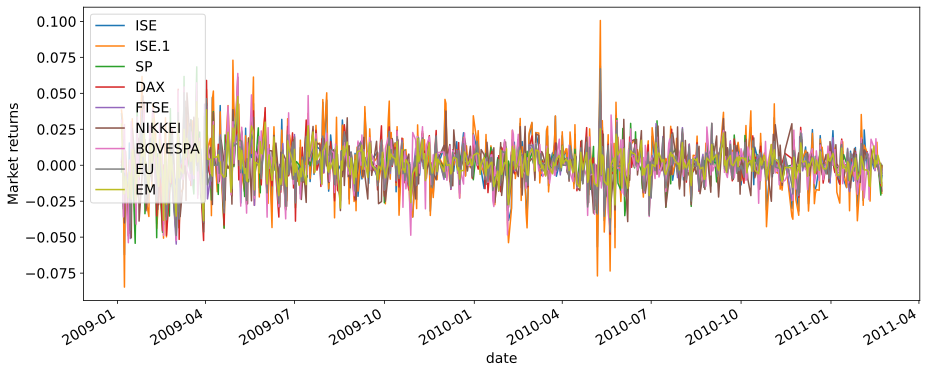

In [102]:
# show some data in line plots
data.plot(figsize=(15,6),ylabel='Market returns')
plt.savefig('Figure_15_03a.png',dpi=300)
plt.show()

In [103]:
# Seaborn's pairplot shows a lot of positive correlations
# I don't show this in the book b/c it's too big, lol.
sns.pairplot(data,height=1.5)
plt.show()

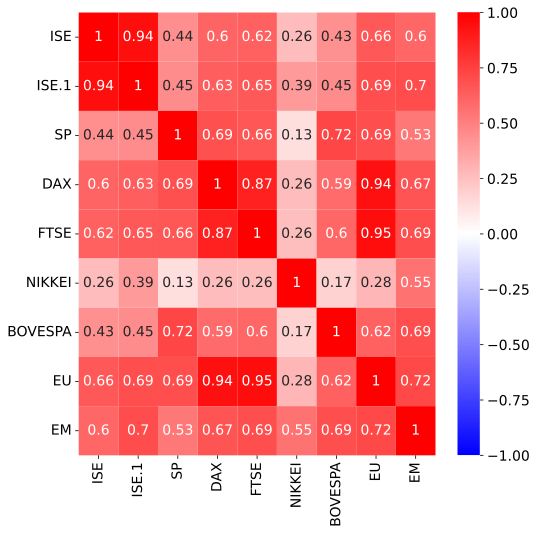

In [104]:
### show the correlation matrix in an image

plt.figure(figsize=(8,8))
heatmap = sns.heatmap(data.corr(),vmin=-1,vmax=1,annot=True,cmap='bwr')
plt.savefig('Figure_15_03b.png',dpi=300)
plt.show()

Now for the PCA. Complete the following code to implement the PCA using the five steps outlined earlier in the slides.

Hint: Find the Complete me comments and substitute with the right code...

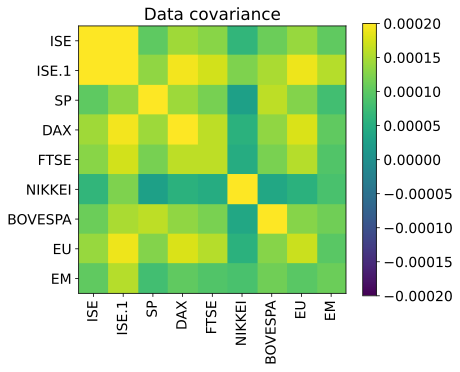

In [105]:
#### now for PCA!

# Step 1: covariance matrix
X = data.values # extract data
X = X - np.mean(X,axis=0,keepdims=True) # mean-center via broadcasting

# note: these data are observations-by-features, so we need X'X, not XX'
covmat = X.T@X / (X.shape[0]-1)

# visualize it
plt.figure(figsize=(6,6))
plt.imshow(covmat,vmin=-.0002,vmax=.0002)
plt.colorbar(shrink=.82)
plt.title('Data covariance')
plt.xticks(range(X.shape[1]),labels=data.columns,rotation=90)
plt.yticks(range(X.shape[1]),labels=data.columns)
plt.savefig('Figure_15_03c.png',dpi=300)
plt.show()

In [106]:
import numpy as np
# Step 2: eigendecomposition
evals, evecs = np.linalg.eigh(covmat)


# Step 3: sort results
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]


# Step 4: component scores
components = data.values @ evecs[:,0:2]
print(components.shape)

# Step 5: eigenvalues to %var
factorScores = evals / np.sum(evals) * 100




(536, 2)


# Exercise 2

The following code shows a scree plot. From your analysis, what can be suggested about the international stock exchanges? How much does the largest compnent accounts for the variance in the data?


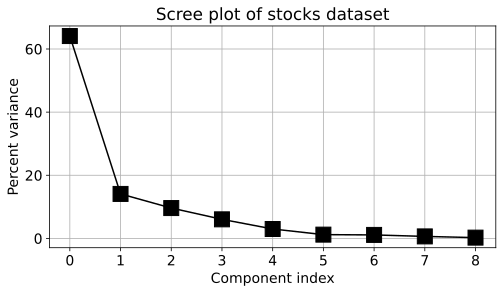

In [107]:

# show scree plot
plt.figure(figsize=(8,4))
plt.plot(factorScores,'ks-',markersize=15)
plt.xlabel('Component index')
plt.ylabel('Percent variance')
plt.title('Scree plot of stocks dataset')
plt.grid()
plt.show()

## 1. What can be suggested about the international stock exchanges?
The international stock exchanges appear to be driven by a common factor, as the first component accounts for around 65% of the variance in the data. This suggests that the stock exchanges tend to move together.


## 2. How much does the largest component accounts for the varians in data
As mentioned, the first component accounts for around 65% of the total variance, which is much higher than all the other components. For example, the second largest component only accounts for around 14% of the variance.

# Exercise 3

Use code to demonstrate several features of PCA:

1. The variance of the component time series (using np.var) equals the eigenvalue associated with that component. You can see the results for the first two components here:

```
    Variance of first two components:
    [0.0013006 0.00028585]

    First two eigenvalues:
    [0.0013006 0.00028585]
```

2. The correlation between principal components (that is, the weighted combinations of the stock exchanges) 1 and 2 is zero, i.e., orthogonal.

3. Visualize the eigenvector weights for the first two components. The weights show how much each variable contributes to the component.
     
Hint: You can use some of the solutions presented in [this solution for Exercise 1 of Chapter 15 in the book](https://github.com/mikexcohen/LinAlg4DataScience/blob/main/LA4DS_ch15.ipynb)

Task 1:
Variance of first two components:
0.001300599548875124
0.00028585232874312464
First two eigenvalues:
[0.0013006  0.00028585] 

Task 2:
[[ 1.00000000e+00 -3.72247549e-17]
 [-3.72247549e-17  1.00000000e+00]]
Task 3:


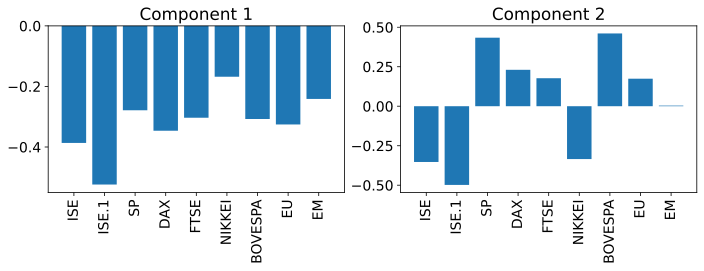

In [108]:
print ("Task 1:")
print("Variance of first two components:")
print (np.var(components[:, 0], ddof=1))
print (np.var(components[:, 1], ddof=1))


print("First two eigenvalues:")
print ((evals[:2]), "\n")


print ("Task 2:")
print (np.corrcoef(components[:, 0], components[:, 1]))

print ("Task 3:")
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(data.columns, evecs[:, 0].real)
plt.title("Component 1")
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.bar(data.columns, evecs[:, 1].real)
plt.title("Component 2")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


# Exercise 4

Reproduce the results using:

1. the SVD of the data covariance matrix and
2. the SVD of the data matrix itself.

Remember that the eigenvalues of $X^T X$ are the squared singular values of $X$; furthermore, the scaling factor on the covariance matrix must be
applied to the singular values to find equivaluence.

Hint: You can use some of the solutions presented in [this solution for Exercise 2 of Chapter 15 in the book](https://github.com/mikexcohen/LinAlg4DataScience/blob/main/LA4DS_ch15.ipynb)

In [ ]:
print ("Task 1:")
U, s, Vt = np.linalg.svd(covmat)

print (s)
print (evals)

print ("So this confirms that the singular values equal the eigenvalues when the matrix is symmetric, same for covmat")

print(Vt.T[:, :2])
print(evecs[:, :2])
print ("The eigenvectors and right singular vectors are identical, confirming that SVD and eigendecomposition are equivalent for symmetric matrices.")


print ("Task 2:")
U, s, Vt = np.linalg.svd(X)

evals_svd = s**2 / (X.shape[0]-1)

print(evals_svd)
print(evals)

print ("This shows that the singular values of the matrix X is identical with the eigendecomposition of the covmat matrix")


Task 1:
[1.30059955e-03 2.85852329e-04 1.95032489e-04 1.22534791e-04
 6.04559244e-05 2.42643361e-05 2.23967857e-05 1.28347506e-05
 5.00103709e-06]
[1.30059955e-03 2.85852329e-04 1.95032489e-04 1.22534791e-04
 6.04559244e-05 2.42643361e-05 2.23967857e-05 1.28347506e-05
 5.00103709e-06]
So this confirms that the singular values equal the eigenvalues when the matrix is symmetric, same for covmat
[[-0.3864847  -0.35298874]
 [-0.52390953 -0.49823792]
 [-0.27860507  0.43379401]
 [-0.34621538  0.23047826]
 [-0.30322542  0.17721358]
 [-0.16781756 -0.33454308]
 [-0.30741897  0.46063876]
 [-0.32544121  0.17416684]
 [-0.24111348  0.00381729]]
[[-0.3864847  -0.35298874]
 [-0.52390953 -0.49823792]
 [-0.27860507  0.43379401]
 [-0.34621538  0.23047826]
 [-0.30322542  0.17721358]
 [-0.16781756 -0.33454308]
 [-0.30741897  0.46063876]
 [-0.32544121  0.17416684]
 [-0.24111348  0.00381729]]
The eigenvectors and right singular vectors are identical, confirming that SVD and eigendecomposition are equivalent

# Exercise 5

The following code generates 2D simulated data. Explain in your own words:
1. The general goal of the code.
2. What are covB and covW?
3. What is the GED axis 1?
4. What are the 5% failed predictions points in the last plot?


1. The general goal of the code:
The goal of the code is to generate two classes of data points and separate them from each other using LDA, to find the direction where the two classes are best separated.

2. What are covB and covW:
covB is the between-class covariance, meaning the variation between the two classes, and covW is the within-class covariance, meaning the variation inside each class.

3. What is the GED axis 1:
it's the direction that GED finds where the two classes are best separated from each other.

4. What are the 5% failed predictions points in the last plot?:
The 5% failed predictions are the points that the model classified incorrectly, for example like points from class 0 predicted as class 1 or the other way around.


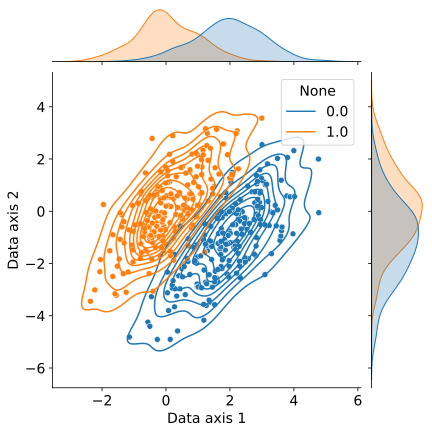

In [110]:
# create the data
N = 200

class1 = np.random.randn(N,2)
class1[:,1] += class1[:,0]
class1 += np.array([2,-1])

class2 = np.random.randn(N,2)
class2[:,1] += class2[:,0]

# for later, it will be convenient to have the data in one matrix
alldata = np.vstack((class1,class2))
labels  = np.append(np.zeros(N),np.ones(N))



# show data in their original data space
ax = sns.jointplot(x=alldata[:,0],y=alldata[:,1],hue=labels)
ax.ax_joint.set_xlabel('Data axis 1')
ax.ax_joint.set_ylabel('Data axis 2')
ax.plot_joint(sns.kdeplot)
plt.savefig('Figure_15_02a.png',dpi=300)
plt.show()

In [111]:
# LDA

# between-class covariance
cmc1 = np.mean(class1,axis=0)
cmc2 = np.mean(class2,axis=0)
covB = np.cov(np.vstack((cmc1,cmc2)).T,ddof=1)

# within-class covariances
cov1 = np.cov(class1.T,ddof=1)
cov2 = np.cov(class2.T,ddof=1)
covW = (cov1+cov2)/2


# LDA via GED
from scipy.linalg import eigh
evals,evecs = eigh(covB,covW)

# sort the solution
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]


# project the mean-centered data onto the GED axes
projA = (alldata-np.mean(alldata,axis=0)) @ evecs  # A=all

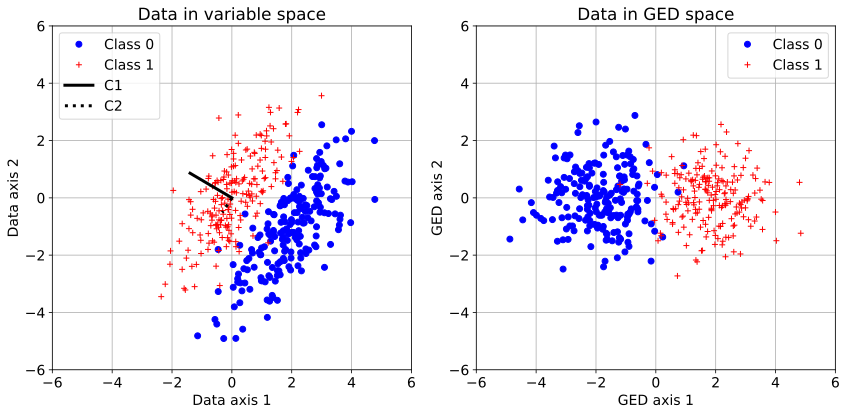

Prediction accuracy: 97.75%


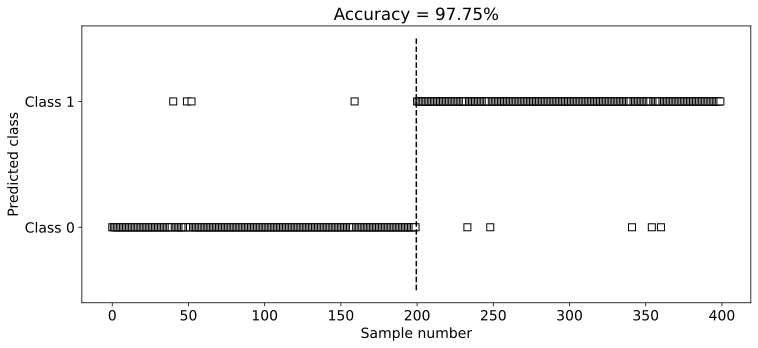

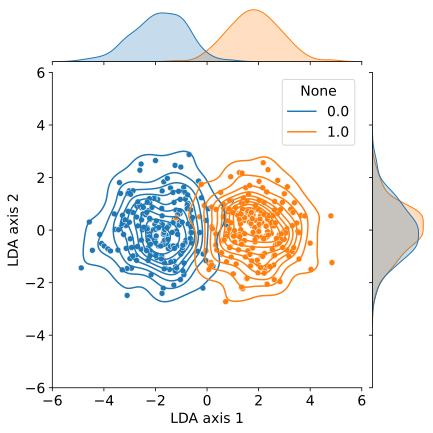

In [112]:
# show the data
_,axs = plt.subplots(1,2,figsize=(12,6))
marker = ['bo','r+']
for i in range(2):
  axs[0].plot(alldata[labels==i,0],alldata[labels==i,1],marker[i],label=f'Class {i}')

axs[0].plot([0,evecs[0,0]],[0,evecs[1,0]],'k-',linewidth=3,label='C1')
axs[0].plot([0,evecs[0,1]],[0,evecs[1,1]],'k:',linewidth=3,label='C2')
axs[0].set_xlabel('Data axis 1')
axs[0].set_ylabel('Data axis 2')
axs[0].set_title('Data in variable space')



# and again in the GED space
for i in range(2):
  axs[1].plot(projA[labels==i,0],projA[labels==i,1],marker[i],label=f'Class {i}')
axs[1].set_xlabel('GED axis 1')
axs[1].set_ylabel('GED axis 2')
axs[1].set_title('Data in GED space')


# common settings
for i in range(2):
  axs[i].axis([-6,6,-6,6])
  axs[i].grid()
  axs[i].legend()

plt.tight_layout()
plt.savefig('Figure_15_06ab.png',dpi=300)
plt.show()


# prediction (converted to ints)
predictedLabel = ( projA[:,0] > 0 )+0

print(f'Prediction accuracy: {100*np.mean( predictedLabel==labels )}%')

# show the results
plt.figure(figsize=(12,5))
plt.plot(predictedLabel,'ks',markersize=7,markerfacecolor='w',linewidth=2)
plt.plot([N-.5,N-.5],[-.5,1.5],'k--')
plt.xlabel('Sample number')
plt.ylabel('Predicted class')
plt.yticks([0,1],labels=['Class 0','Class 1'])
plt.title(f'Accuracy = {100*np.mean(predictedLabel==labels):.2f}%')
plt.savefig('Figure_15_06c.png',dpi=300)
plt.show()


# redraw the jointplot in the GED space (used in Figure 2)
ax = sns.jointplot(x=projA[:,0],y=projA[:,1],hue=labels,xlim=[-6,6],ylim=[-6,6])
ax.ax_joint.set_xlabel('LDA axis 1')
ax.ax_joint.set_ylabel('LDA axis 2')
ax.plot_joint(sns.kdeplot)
plt.savefig('Figure_15_02b.png',dpi=300)
plt.show()

